# Intrusion Detection System (IDS) Project  
This notebook performs:
1. **Exploratory Data Analysis (EDA), Cleaning & Processing**
2. **Machine Learning Models** (Decision Tree, XGBoost)
3. **Deep Learning Model (CNN)**
4. **Explainable AI (XAI) with SHAP & LIME**
5. **Deployment Pipeline (Joblib + FastAPI skeleton)**

In [16]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# XAI
import shap
try:
    from lime import lime_tabular
    LIME_AVAILABLE = True
except:
    LIME_AVAILABLE = False

# Persistence
import joblib

## 1. Data Loading & Initial EDA

In [10]:
# Load dataset
data_path = "/kaggle/input/ids-intrusion-csv/02-14-2018.csv"
df = pd.read_csv(data_path)

# Basic info
print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (1048575, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

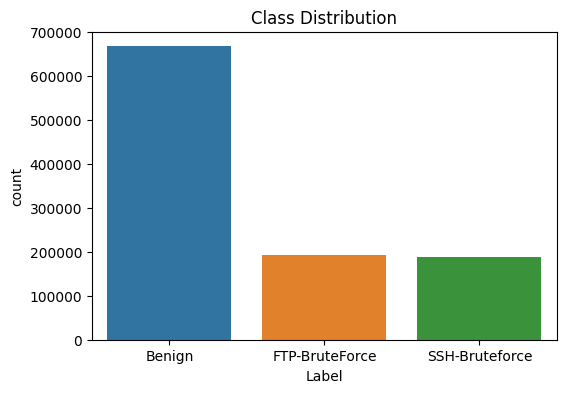

Flow Byts/s         2277
Dst Port               0
Bwd Byts/b Avg         0
Fwd Pkts/b Avg         0
Fwd Byts/b Avg         0
Bwd Seg Size Avg       0
Fwd Seg Size Avg       0
Pkt Size Avg           0
Down/Up Ratio          0
ECE Flag Cnt           0
CWE Flag Count         0
URG Flag Cnt           0
ACK Flag Cnt           0
PSH Flag Cnt           0
RST Flag Cnt           0
SYN Flag Cnt           0
FIN Flag Cnt           0
Pkt Len Var            0
Pkt Len Std            0
Fwd Blk Rate Avg       0
dtype: int64


In [11]:
# EDA
plt.figure(figsize=(6,4))
sns.countplot(x=df['Label'])
plt.title("Class Distribution")
plt.show()

# Missing values check
print(df.isnull().sum().sort_values(ascending=False).head(20))

## 2. Data Preprocessing

In [17]:
# Drop irrelevant columns (example: Timestamp)
if 'Timestamp' in df.columns:
    df = df.drop(columns=['Timestamp'])

# replace infinity value as null value
    df = df.replace(["Infinity", "infinity"], np.inf)
    df = df.replace([np.inf, -np.inf], np.nan)

    # drop all null values
    df.dropna(inplace=True)

target = 'Label'
X = df.drop(columns=[target])
y = df[target]

# Identify numeric & categorical features
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

label_encoder = LabelEncoder()
df['Label']= label_encoder.fit_transform(df['Label'])
df['Label'].unique()
df['Label'].value_counts()

# Preprocess
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
    # OneHotEncoder could be added if you have categorical features
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop')
# Encode categorical features if any
df = pd.get_dummies(df, drop_first=True)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Machine Learning Models — Decision Tree & XGBoost

In [18]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132762
           1       1.00      1.00      1.00     38671
           2       1.00      1.00      1.00     37518

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



In [19]:
# XGBoost Classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132762
           1       1.00      1.00      1.00     38671
           2       1.00      1.00      1.00     37518

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



## 4. Deep Learning Model — CNN

In [20]:
# CNN expects 3D input (samples, timesteps, features)
X_train_cnn = np.expand_dims(X_train, axis=2)
X_test_cnn = np.expand_dims(X_test, axis=2)

cnn_model = keras.Sequential([
    layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1],1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = cnn_model.fit(X_train_cnn, y_train, validation_split=0.2, epochs=5, batch_size=256, verbose=1)
cnn_eval = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print("CNN Test Accuracy:", cnn_eval[1])

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
2025-09-07 08:19:02.550327: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 55s 20ms/step - accuracy: 0.7036 - loss: -967778.3750 - val_accuracy: 0.7678 - val_loss: -21551730.0000
Epoch 2/5
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 52s 20ms/step - accuracy: 0.7031 - loss: -47549724.0000 - val_accuracy: 0.7692 - val_loss: -211678336.0000
Epoch 3/5
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 52s 20ms/step - accuracy: 0.7041 - loss: -298453216.0000 - val_accuracy: 0.7688 - val_loss: -774785792.0000
Epoch 4/5
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 53s 20ms/step - accuracy: 0.7023 - loss: -941017344.0000 - val_accuracy: 0.7690 - val_loss: -1941906304.0000
Epoch 5/5
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 52s 20ms/step - accuracy: 0.7032 - loss: -2206362624.0000 - val_accuracy: 0.7690 - val_loss: -4027911168.0000
CNN Test Accuracy: 0.7694818377494812


## 5. Explainable AI (XAI)

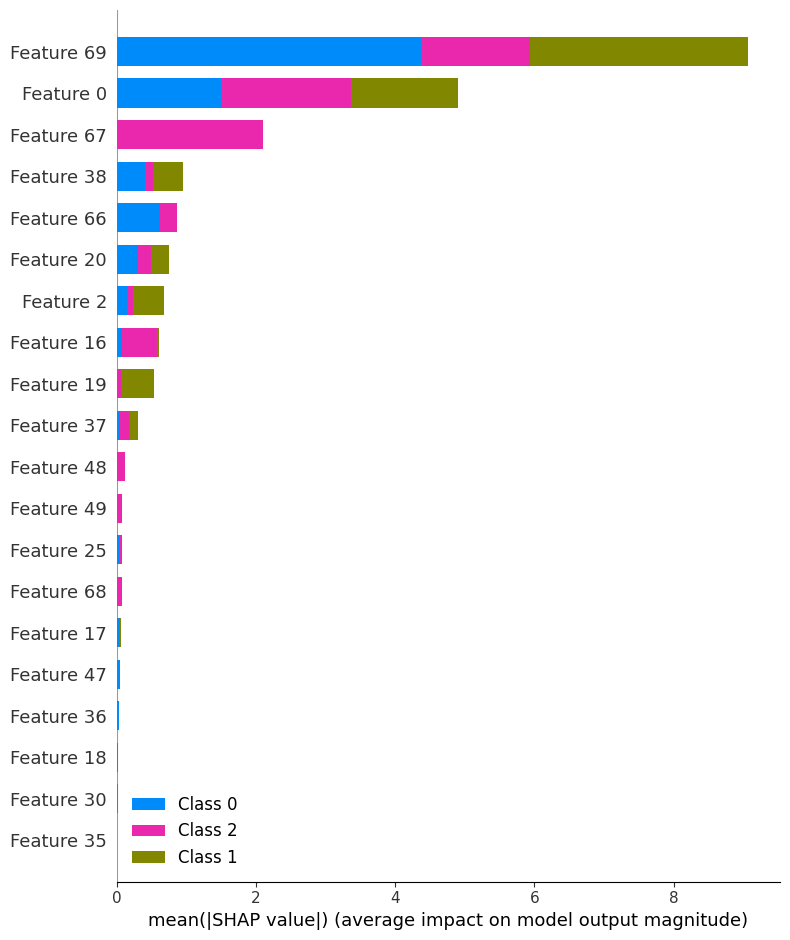

  0%|          | 0/50 [00:00<?, ?it/s]

Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=3.487e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
Regressors in active set degenerate. Dropping a regressor, after 11 iterations, i.e. alpha=1.743e-03, with an active set of 9 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 17 iterations, alpha=1.182e-03, previous alpha=1.151e-03, with an active set of 14 regressors.
Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=1.987e-02, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
Early stopping the lars path, as the residues are small and the current v

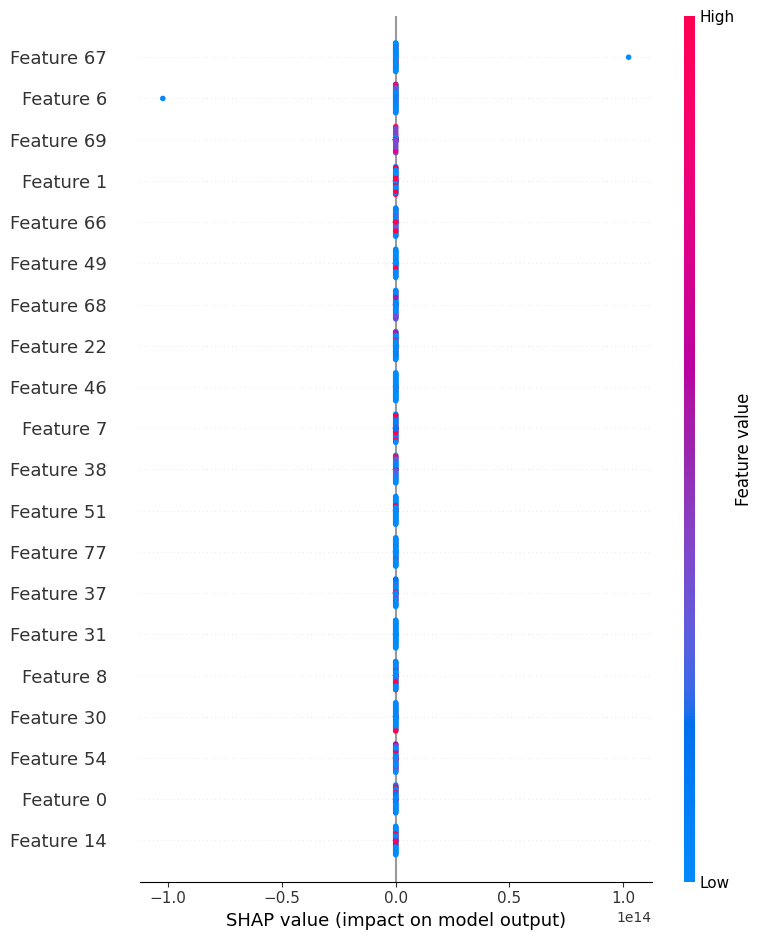

In [21]:
# SHAP for XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:200])
shap.summary_plot(shap_values, X_test[:200], show=False)
plt.show()

# SHAP for CNN using KernelExplainer
try:
    background = shap.sample(X_train[:500], 100)
    f = lambda inp: cnn_model.predict(np.expand_dims(inp, axis=2), verbose=0).flatten()
    explainer_cnn = shap.KernelExplainer(f, background)
    shap_vals = explainer_cnn.shap_values(X_test[:50], nsamples=50)
    shap.summary_plot(shap_vals, X_test[:50], show=False)
    plt.show()
except Exception as e:
    print("SHAP CNN skipped:", e)

# LIME
if LIME_AVAILABLE:
    try:
        explainer = lime_tabular.LimeTabularExplainer(
            training_data=X_train,
            feature_names=df.drop(columns=[target]).columns.tolist(),
            class_names=['Normal','Attack'],
            discretize_continuous=True
        )
        exp = explainer.explain_instance(X_test[0], xgb.predict_proba, num_features=10)
        exp.show_in_notebook(show_table=True)
    except Exception as e:
        print("LIME skipped:", e)

## 6. Deployment Pipeline

In [22]:
# Save best model (XGBoost)
os.makedirs("artifacts", exist_ok=True)
joblib.dump(xgb, "artifacts/xgb_model.joblib")
joblib.dump(scaler, "artifacts/scaler.joblib")

print("Models saved in artifacts/ folder")

# FastAPI Skeleton
fastapi_app = r'''
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()
model = joblib.load("artifacts/xgb_model.joblib")
scaler = joblib.load("artifacts/scaler.joblib")

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict")
def predict(features: dict):
    X = pd.DataFrame([features])
    X_scaled = scaler.transform(X)
    preds = model.predict(X_scaled)
    proba = model.predict_proba(X_scaled)[0,1]
    return {"prediction": int(preds[0]), "probability": float(proba)}
'''
with open("/mnt/data/fastapi_app.py", "w") as f:
    f.write(fastapi_app)

Models saved in artifacts/ folder


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/fastapi_app.py'